# FIE463 Term Paper 2

## Course Information
**Course:** Numerical Methods in Macroeconomics and Finance using Python  
**Instructor:** Richard Foltyn  

## Submission Details
**Candidate Numbers:** [114, 117, 129]  
**Submission Date:** April 10th, 2025  
**Total Excecution Time**: 2 minutes and 4.19 seconds

## AI statement
The work was done independently, with AI (ChatGPT) used only for general refinements, specifically making the plots more presentable and fixing typos and syntax errors in the code.

## Introduction

This project analyzes portfolio allocations among U.S. households using data from the Survey of Consumer Finances (SCF) covering the years 1989 to 2022. The SCF is a repeated cross-sectional survey conducted by the Federal Reserve Board to study household wealth and financial behavior.

This project addresses two primary research questions:
1.   Which groups of the population are more likely to participate in the stock market, and can we predict participation using classification models?
2.   Conditional on participation, what fraction of financial wealth is held in stock and can we model the variation in risky asset shares across households?

The analysis proceeds in several stages:
*   First, we preprocess and merge the SCF datasets across years, creating a cleaned and representative sample.
*   Next, we apply machine learning models to predict stock market participation and estimate households' risky asset shares.
*   Finally, we evaluate the performance of different modeling approeaches and discuss key patterns observed in the data.






## Packages and declaration

In [1]:
# ----------------------------
# General Setup
# ----------------------------

import os              # File and operating system utilities
from glob import glob  # Pattern matching for file retrieval
import time            # Timing execution

# ----------------------------
# Core Libraries
# ----------------------------

import numpy as np               # Numerical operations
import pandas as pd              # Data handling and manipulation
import matplotlib.pyplot as plt  # Plotting and visualization

# ----------------------------
# Scikit-Learn: Model Selection and Evaluation
# ----------------------------

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.metrics import (
    mean_squared_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay
)

# ----------------------------
# Scikit-Learn: Linear Models
# ----------------------------

from sklearn.linear_model import (
    LinearRegression, RidgeCV, LassoCV, ElasticNetCV,
    LogisticRegression, LogisticRegressionCV
)

# ----------------------------
# Scikit-Learn: Preprocessing and Pipelines
# ----------------------------

from sklearn.preprocessing import StandardScaler, OneHotEncoder, PolynomialFeatures
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.impute import SimpleImputer

# ----------------------------
# Scikit-Learn: Other Models and Utilities
# ----------------------------

from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA


## Timer: Start Total Excecution Time

In [2]:
# Start total notebook timer
global_notebook_start_time = time.perf_counter() # Use perf_counter for higher precision timing
print(f"Notebook execution started at {time.strftime('%Y-%m-%d %H:%M:%S')}")
print("-" * 60)

Notebook execution started at 2025-04-09 17:52:08
------------------------------------------------------------


## Part 1 - Data Preprocessing

### Step 1: Read and Merge All SCF Files

Firt, we load each SCF survey file separately. For each dataset, we extract the corresponding survey year from the file name and append it as a new column. Each processed dataset is added to a list, which will be used in the following steps for filtering, sampling, and feature creation. This setup allows us to apply the same processing pipeline to each year separately.

In [3]:
# ----------------------------
# Step 1 — Load and label survey files
# ----------------------------
# Set your directory for the files.

def load_scf_data(data_dir):
    """
    Load SCF files, add year column to each, return list of DataFrames.
    """

    # Retrieve list of SCF file paths
    file_paths = sorted(glob(os.path.join(data_dir, "SCF_*.csv")))

    # Initialize empty list to store datasets from all survey years
    datasets = []

    # Load each survey file, add year column, and store in list
    for path in file_paths:
        year = int(os.path.basename(path).split("_")[1].split(".")[0])
        df = pd.read_csv(path)
        df["year"] = year       # Add survey year as a new column
        datasets.append(df)     # Append processed df to list

    return datasets

### Step 2: Sample Restrictions Per Year


In this step, we apply a series of restrictions to each survey year's dataset to ensure a clean and representative sample for analysis. First, we compute the weighted 0.1st and 99th percentiles of the net worth distribution, using the provided sampling weights to accurately reflect the population. Additionally, we restrict the sample to households where the reference person is between 20 and 80 years of age, and drop observations with negative gross assets or wage income. The filtered datasets are stored for further processing in the next steps.

In [4]:
# ----------------------------
# Step 2 — Apply sample restrictions
# ----------------------------
def restrict_sample(df):
    """
    Apply sample restrictions:
    - Age 20–80
    - Assets >= 0, wageinc >= 0
    - Net worth within weighted 0.1–99 percentile
    """

    # Compute the weighted 0.1st and 99th percentiles of net worth
    p001, p99 = np.percentile(
        df["networth"],
        [0.1, 99],
        weights=df["weight"],
        method="inverted_cdf"
    )

    restrict = (
        (df["age"] >= 20) & (df["age"] <= 80) &   # Age filter
        (df["assets"] >= 0) &                     # Non-negative assets
        (df["wageinc"] >= 0) &                    # Non-negative wage income
        (df["networth"] >= p001) &                # Top 1% and bottom 0.1% trimmed
        (df["networth"] <= p99)
    )
    return df.loc[restrict]


### Step 3: Weighted Sampling (10,000 Observations Per Year)


In this setup, we draw 10,000 observations with replacement from each restricted survey year to create a representative unweighted sample. Sampling is performed using the SFC-provided weights, so the selected sample accurately reflects the population without requiring weights in later analysis. A global random generator is used to ensure reproducibiltiy, and its instance is passed into the sampling function for consistent draws across survey years.


In [5]:
# ----------------------------
# Step 3 — Weighted sampling (10,000 per year)
# ----------------------------

def sample_scf(df, n=10_000, rng=None):
    """
    Draw weighted sample of n observations from df.
    """
    return df.sample(
        n=n,                  # Number of observations to draw
        weights=df["weight"], # Use SFC sampling weights
        replace=True,         # Draw with replacement
        random_state=rng      # Ensure reproducibility
    )


### Step 4: Creation of Rank Variables and Indicator Variables




To improve numerical stability in the subsequent modeling stages, we create normalized rank variables for the key financial characteristics: `assets`, `networth`, `wageinc`, `liqassets`, `debt`, `houses`, and `finassets`. Each rank is computed within each survey year, assigning a value between 0 and 1, where 0 corresponds to the lowest value, 0.5 to the median, and 1 to the maximum.

Afterwards, we define several indicator variables capturing demographic characteristics and stock market participation:
*   `college`identifies households where the reference person holds a bachelor's degree or higher;
*   `white` indicates non-Hispanic white households;
*   `part` measures direct stock market participation via stocks or mutual funds;
*   `part_any` captures any stock market particiaption, including indirect holdings through retirement accounts, insurance products, or managed funds.

In [6]:
# ----------------------------
# Step 4 — Feature engineering
# ----------------------------

def add_features(df, rank_vars):
    """
    Add rank-based variables and binary indicators.
    """

    # Compute normalized rank (0-1) for each financial variable
    for var in rank_vars:
        df[f"{var}_rank"] = df[var].rank(pct=True)

    # Create indicator for college education (bachelor's degree or higher)
    df["college"] = (df["educ"] >= 4).astype(int)

    # Create indicator for white non-Hispanic households
    df["white"] = (df["race"] == 1).astype(int)

    # Create indicator for direct stock market particiaption
    df["part"] = ((df["stocks"] > 100) | (df["stkmutfnd"] > 100)).astype(int)

    # Create indicator for any stock market participation
    df["part_any"] = (df["equity"] > 100).astype(int)

    return df

### Step 5: Consolidation of Processed Survey Waves


In this step, we finalize the preprocessing pipeline by applying all previous steps to each survey year and merging the results into a single dataset. For each year, we apply sample restrictions, draw a weighted sample of 10,000 households, and generate rank variables and binary indicators. The processed datasets are then concatenated into one DataFrame containing 120,000 observations.

A global random number generator initialized with a fixed seed (1234) is used to ensure reproducibility across years. The resulting consolidated dataset will serve as the input for the next stages of the analysis.

In [7]:
# ----------------------------
# Step 5 — Run preprocessing
# ----------------------------

RANDOM_STATE = 1234  # Global random seed for reproducibility
rng = np.random.default_rng(RANDOM_STATE)  # Initialize random number generator

# Define path to folder containing SCF CSV files
data_dir = r"C:\Users\" 

# Define variables for which to compute within-year percentile ranks
rank_vars = ['assets', 'networth', 'income', 'wageinc',
             'liqassets', 'debt', 'houses', 'finassets']

# ----------------------------
# Preprocess all years
# ----------------------------
def preprocess_scf(data_dir, rng_instance, rank_vars):
    """
    Complete SCF preprocessing pipeline.
    """
    # Load all SCF CSV files with year label
    all_years = load_scf_data(data_dir)
    final_data = []

    # Process each year separately
    for df in all_years:
        df = restrict_sample(df)
        df = sample_scf(df, rng=rng_instance)
        df = add_features(df, rank_vars)
        final_data.append(df)

    # Combine all years into single dataset
    df_all = pd.concat(final_data, ignore_index=True)
    return df_all

# Run full preprocessing pipeline
df = preprocess_scf(data_dir, rng_instance=rng, rank_vars=rank_vars)

# Prepare columns to inspect: year, indicators, and rank features
rank_cols = [f'{var}_rank' for var in rank_vars]
display_cols = ['year', 'college', 'white', 'part', 'part_any'] + rank_cols

# Preview first few rows of key variables
print("Final dataset shape:", df.shape)
print("First few rows of the final dataset:")
print(df[display_cols].head())

Final dataset shape: (120000, 61)
First few rows of the final dataset:
   year  college  white  part  part_any  assets_rank  networth_rank  \
0  1989        0      1     1         1      0.85400        0.85150   
1  1989        0      1     0         0      0.98730        0.98545   
2  1989        0      0     0         0      0.67575        0.73945   
3  1989        0      1     0         0      0.76945        0.79400   
4  1989        0      1     0         0      0.39215        0.47650   

   income_rank  wageinc_rank  liqassets_rank  debt_rank  houses_rank  \
0      0.88095       0.94345         0.59410    0.84150      0.89180   
1      0.95380       0.96245         0.83685    0.97460      0.99260   
2      0.60595       0.42950         0.69975    0.30345      0.70935   
3      0.70575       0.30505         0.97645    0.67390      0.54505   
4      0.25205       0.33935         0.43500    0.12595      0.45415   

   finassets_rank  
0         0.81270  
1         0.61255  
2        

## Part 2 - Exploratory data analysis

### Step 1: Correlation Analysis with Stock Market Participation



As a first step in the exploratory analysis, we examine the correlations between all available numeric variables and the two stock market participation indicators, `part` and `part_any`. To ensure meaningful results, we exclude direct measures of stock ownership, such as `part`, `part_any`, `stocks`, `stmkutfnd`, and `equity` from the analysis.

We compute pairwiser Pearson correlation coefficients and identify the 20 variables most strongly associated with stock market participation. This analysis provides intiital insights into which financial and demographic characteristics are most predictive of direct and indirect stock market participation.

In [8]:
# ============================================
# Step 1: Correlation with part and part_any
# ============================================

# Exclude obvious predictors and targets
excluded = ['part', 'part_any', 'stocks', 'stkmutfnd', 'equity']

# Select numeric columns
numeric_cols = df.select_dtypes(include=['number']).columns.tolist()

# Keep only those not excluded
correlation_vars = [col for col in numeric_cols if col not in excluded]

# Compute correlation matrix
cor_matrix = df[correlation_vars + ['part', 'part_any']].corr()

# Extract correlations with part and part_any
cor_with_part = cor_matrix['part'].drop(labels=['part', 'part_any'])
cor_with_part_any = cor_matrix['part_any'].drop(labels=['part', 'part_any'])

# Combine into a table
cor_table = pd.DataFrame({
    'corr_with_part': cor_with_part,
    'corr_with_part_any': cor_with_part_any
})

# Identify top 20 variables most strongly correlated
top_corr = cor_table.abs().max(axis=1).sort_values(ascending=False).head(20)
cor_table_top20 = cor_table.loc[top_corr.index].sort_values(by='corr_with_part_any', ascending=False)

# Display the top 20 variables
print("Top 20 variables most correlated with part or part_any:")
display(cor_table_top20.round(3))

Top 20 variables most correlated with part or part_any:


,corr_with_part,corr_with_part_any
finassets_rank,0.488,0.655
assets_rank,0.433,0.533
income_rank,0.360,0.520
networth_rank,0.421,0.482
liqassets_rank,0.389,0.463
wageinc_rank,0.221,0.416
houses_rank,0.324,0.400
educ,0.299,0.380
takefinrisk,0.264,0.352
debt_rank,0.171,0.330


Stock market participation is primarily driven by financial resources, as evidenced by the strong correlations of `finassets_rank`, `assets_rank`, `income_rank`, and `networth_rank` with both participation measures.

Higher financial wealth facilitates access to the stock market by relaxing liquidity constraints and covering fixed costs of entry, making investment feasible for a broader share of households.
`Finassets_rank` in particular, with a correlation of 0.655 with broader participation (`part_any`), underscores the pivotal role of liquid financial assets relative to illiquid components such as housing.

Education (`educ`, `college`) and willingness to take financial risk (`takefinrisk`) are also significant factors, reflecting the importance of informational efficiency and risk tolerance in investment decisions.
Households with greater human capital are better equipped to process financial information and act upon investment opportunities, while higher risk tolerance reduces barriers to allocating resources to volatile assets like equities.

Debt indicators (`debt_rank`, `debt`) show moderate correlations, suggesting that debt influences participation indirectly, likely through its interaction with perceived financial security and liquidity needs.
Income flows (`wageinc_rank`) and housing assets (`houses_rank`) further contribute to explaining participation, reinforcing that both current income and accumulated wealth jointly determine household investment behavior.

The identified correlation structure reflects the multifaceted economic channels underlying portfolio choice, integrating liquidity, human capital, income stability, and behavioral traits into participation outcomes.

### Step 2: Plotting of 'part' and 'part_any'

This section examines whether stock market participation varies systematically across observable household characteristics.

Participation rates (`part` and `part_any`) are analyzed across survey years, wealth and income deciles, age groups, education levels, marital status and sex combinations, racial categories, employment status, and financial risk attitudes.

Comparative line and bar charts provide a structured visualization of participation rates across subgroups, enabling an initial assessment of demographic and economic patterns.

All graphs are generated using a unified plotting function to maintain consistency in presentation and scale.

In [9]:
# ============================================
# Reusable Plotting Function for Parts 2 and 4
# ============================================

def plot_analysis_grid(df, configs, num_cols, figure_title, default_ylabel, show_legend, base_fig_height=4, figsize=None):
    """
    Generate a grid of plots (line or bar) based on a list of configuration settings.
    """

    # Check if there are any plots to generate
    num_plots = len(configs)
    if num_plots == 0:
        print("No plots configured.")
        return

    # ============================================
    # Setup Figure and Axes
    # ============================================

    nrows = (num_plots + num_cols - 1) // num_cols  # Compute necessary number of rows
    if figsize is None:
        figsize_width = 6 * num_cols                # Approximate width per plot
        figsize_height = base_fig_height * nrows    # Height scales with number of rows
        figsize = (figsize_width, figsize_height)

    # Create figures and axes grid
    fig, axes = plt.subplots(nrows, num_cols, figsize=figsize, sharey=False)

    # Ensure axes is always an array (even for a single plot)
    if num_plots == 1:
        axes = np.array([axes])
    axes = axes.flatten()

    last_plot_index = -1 # Keep track of the last successfully plotted index

    # ============================================
    # Loop Over Configurations and Create Plots
    # ============================================

    for i, config in enumerate(configs):
        ax = axes[i] # Current subplot axis
        try:
            # Unpack the configuration tuple
            group_var, target_vars, plot_type, title, group_labels, rotation, sort_index, ylabel = config

            # Ensure target_vars is always a list
            if not isinstance(target_vars, list):
                target_vars = [target_vars]

            # Group Data by Specified Variable and Compute Means
            group_means = df.groupby(group_var, observed=False)[target_vars].mean()

            # Sort group index
            if sort_index is not None:
                try:
                    group_means = group_means.reindex(sort_index, axis=0)
                except Exception as e:
                    print(f"Warning: Could not sort index for {group_var}. Error: {e}")

            # Prepare x-axis values and labels
            x_values_raw = group_means.index
            x_labels_display = x_values_raw.map(group_labels) if group_labels else x_values_raw
            x_ticks = np.arange(len(x_labels_display))

            # ============================================
            # Plotting Logic (Bar or Line)
            # ============================================

            num_targets = len(target_vars) # How many variables to plot per graph
            bar_width = 0.8 / num_targets if plot_type == 'bar' and num_targets > 0 else 0.8

            # Loop over each target variable to plot
            for j, var in enumerate(target_vars):
                y_values = group_means[var]
                if plot_type == 'line':
                    ax.plot(x_ticks, y_values, marker='o', linestyle='-', label=var)
                elif plot_type == 'bar':
                    offset = (j - (num_targets - 1) / 2) * bar_width
                    ax.bar(x_ticks + offset, y_values, width=bar_width, label=var)
                else:
                    raise ValueError(f"Invalid plot_type '{plot_type}' for {group_var}")

            # ============================================
            # Formatting the Current Subplot
            # ============================================¨

            # Set x-axis ticks and labels
            ax.set_xticks(x_ticks)
            ax.set_xticklabels(x_labels_display, rotation=rotation, ha='right' if rotation > 0 else 'center')

            # Set x-axis labels and title
            ax.set_xlabel(group_var.replace('_', ' ').title()) # Default xlabel based on group_var
            ax.set_ylabel(ylabel or default_ylabel)            # Use specific or default ylabel
            ax.set_title(title)                                # Set title from config

            # Add legend if requested
            if show_legend and num_targets > 0 and any(ax.get_legend_handles_labels()):
                 ax.legend()

            # Adds grid to subplot
            ax.grid(True, linestyle='--', alpha=0.6)

            last_plot_index = i # Update last successful index

        except KeyError as e:
             # ============================================
             # Handle Missing Column Error
             # ============================================
             print(f"Error generating plot {i+1}: Column missing - {e}")
             ax.set_title(f"Error: Missing Column {e}")
             ax.axis('off') # Hide axis on error
        except Exception as e:
             # ============================================
             # Handle Other Plotting Errors
             # ============================================
             group_var_name = config[0] if len(config) > 0 else "Unknown"
             print(f"Error generating plot {i+1} for '{group_var_name}': {e}")
             ax.set_title(f"Error plotting '{group_var_name}'")
             ax.axis('off') # Hide axis on error


    # ============================================
    # Final Figure Formatting
    # ============================================

    # Hide any unused axes in the grid
    for j in range(last_plot_index + 1, len(axes)):
        axes[j].axis('off')

    # Set overall figure title
    plt.suptitle(figure_title, fontsize=16, y=1.02)

    # Adjust layout to avoid overlap
    plt.tight_layout(rect=[0, 0.03, 1, 0.97])

    # Display the final figure
    plt.show()



--- Generating Part 2: Average Stock Market Participation Plots ---


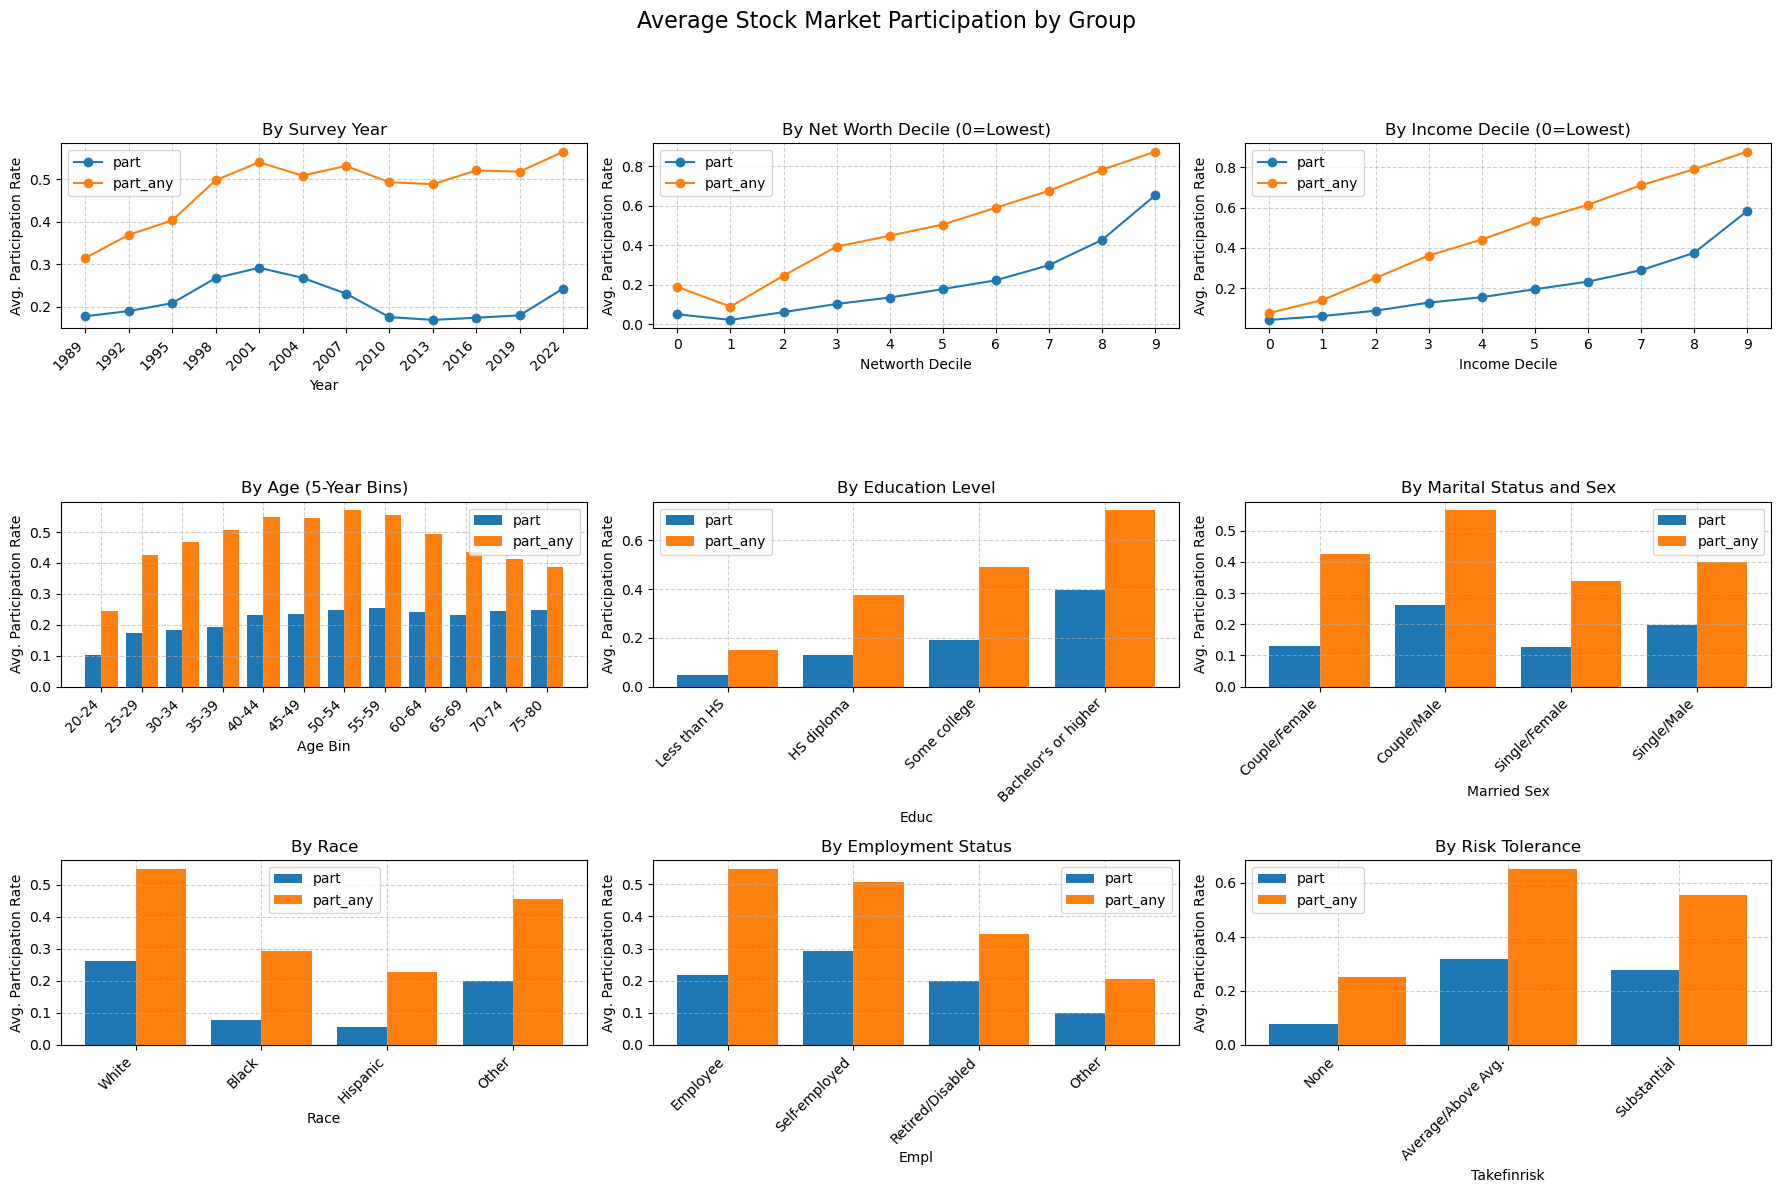

In [10]:
# ============================================
# Execute Plotting — Part 2: Stock Market Participation
# ============================================

# Create net worth and income deciles (0 = lowest, 9 = highest)
df['networth_decile'] = pd.qcut(df['networth_rank'], 10, labels=False, duplicates='drop')
df['income_decile'] = pd.qcut(df['income_rank'], 10, labels=False, duplicates='drop')

# Create 5-year age bins from 20 to 80
age_bins = list(range(20, 81, 5))  # includes 80
age_labels = [f"{a}-{a+4}" if a < 75 else "75-80" for a in age_bins[:-1]]
df['age_bin'] = pd.cut(df['age'], bins=age_bins, labels=age_labels, right=True)

# Create combined marital status and sex variable
df['married_sex'] = df['married'].map({0: 'Single', 1: 'Couple'}) + '/' + df['female'].map({0: 'Male', 1: 'Female'})

# Mappings for clear category labels in plots
educ_labels = {1: 'Less than HS', 2: 'HS diploma', 3: 'Some college', 4: "Bachelor's or higher"}
race_labels = {1: 'White', 2: 'Black', 3: 'Hispanic', 4: 'Other'}
empl_labels = {1: 'Employee', 2: 'Self-employed', 3: 'Retired/Disabled', 4: 'Other'}
risk_labels = {0: 'None', 1: 'Average/Above Avg.', 2: 'Substantial'}

# ============================================
# Configure Subplots for Analysis
# ============================================

# Define configurations for each subplot
# Structure: (group_by_column, target_columns, plot_type, plot_title,
#             label_map, x_tick_rotation, sort_order, y_axis_label)
plot_configs_part2 = [
    ('year', ['part', 'part_any'], 'line', 'By Survey Year', None, 45, None, "Avg. Participation Rate"),
    ('networth_decile', ['part', 'part_any'], 'line', 'By Net Worth Decile (0=Lowest)', None, 0, None, "Avg. Participation Rate"),
    ('income_decile', ['part', 'part_any'], 'line', 'By Income Decile (0=Lowest)', None, 0, None, "Avg. Participation Rate"),
    # Categorical plots (we use bar charts)
    ('age_bin', ['part', 'part_any'], 'bar', 'By Age (5-Year Bins)', None, 45, None, "Avg. Participation Rate"), # Use age_bin interval index
    ('educ', ['part', 'part_any'], 'bar', 'By Education Level', educ_labels, 45, sorted(educ_labels.keys()), "Avg. Participation Rate"), # Sort by key
    ('married_sex', ['part', 'part_any'], 'bar', 'By Marital Status and Sex', None, 45, None, "Avg. Participation Rate"),
    ('race', ['part', 'part_any'], 'bar', 'By Race', race_labels, 45, sorted(race_labels.keys()), "Avg. Participation Rate"),
    ('empl', ['part', 'part_any'], 'bar', 'By Employment Status', empl_labels, 45, sorted(empl_labels.keys()), "Avg. Participation Rate"),
    ('takefinrisk',     ['part', 'part_any'], 'bar',  'By Risk Tolerance', risk_labels,  45, sorted(risk_labels.keys()), "Avg. Participation Rate"), # Sort by key, rot 0
]

# ============================================
# Generate and Display the Plot Grid
# ============================================

print("\n--- Generating Part 2: Average Stock Market Participation Plots ---")

# Call the reusable plot function with the configurations defined above
plot_analysis_grid(                     # Call the combined function
    df=df,                              # Pass the main DataFrame
    configs=plot_configs_part2,         # Use the configurations defined above
    num_cols=3,                         # Arrange in 3 columns
    figure_title="Average Stock Market Participation by Group",
    default_ylabel="Avg. Participation Rate", # Default Y label for these plots
    show_legend=True                    # Show legend (for part vs part_any)
)

##### **Group-Level Participation Patterns**

This section addresses two questions:
*   what fraction of United States households participate in the stock market, either through direct ownership of equities or indirect holdings via retirement accounts and mutual funds, and
*   which groups of the population are more likely to participate.

Overall participation in equity markets remains limited to a subset of households, with significant variation across socio-economic groups. Households with higher wealth and income are much more likely to participate, reflecting the role of fixed costs, liquidity constraints, and differences in risk tolerance that disproportionately affect lower-wealth households.

Education is a strong predictor of participation. Individuals holding a college degree or higher show substantially greater involvement compared to those with only secondary education. Greater financial literacy, improved access to financial products, and a better understanding of how risk diversification contribute to this pattern.

Participation rates increase with age, peaking between 55 and 65 years, consistent with the accumulation of savings and longer experience with financial markets. A modest decline is observed after retirement, reflecting increased liquidity needs and reduced willingness to bear investment risk.

Racial disparities are also evident. White households participate in the stock market at significantly higher rates than Black and Hispanic households. This highlights persistent inequalities in financial market access across racial groups.

Marital status is positively correlated with participation. Married households invest more frequently than single households, likely due to pooled resources, enhanced financial stability, and greater capacity for risk sharing.

Across all groups, indirect participation through retirement accounts and mutual funds is more common than direct stockholding. Access to employer-sponsored plans and institutional investment products plays a critical role, especially among households with higher incomes and educational attainment.

In sum, stock market participation is concentrated among households with greater financial resources, higher education levels, and more stable demographic profiles, while substantial parts of the population remain outside the equity market.


## Part 3: Predicting Stock Market Participation

In this part, we focus on predicting stock market participation among U.S. households based on demographic characteristics and survey information. We formulate this as a classification problem and utilize machine learning techniques from `scikit-learn`.

We proceed in three steps:
1.   We first construct a stratified train-test split to ensure that the distribution of survey years and participation status is preserved in both samples.
2.   We then estimate baseline classification models using a limited set of demographic predictors.
3.   Finally, we augment the models with additional features to assess improvements in predictrive performance.

Throughout, we evaluate model quality using a range of classification metrics, including accuracy, precision, recall, and F1 score. All random processes use a fixed random seed to ensure reproducibility.



### Step 3.1: Train-Test Split with Stratification

Before fitting predictive models, it is essential to divide the data into a training set, used for model estimation, and a test set, used exclusively for performance evaluation. To avoid introducing biases and to ensure that both the training and test samples are representative, we stratify the split based on both the survey year and the participation indicator.

Specifically, we define 24 strata corresponding to the 12 survey years (1989-2022) and the two possible values of participation (`part=0` or `part=1`). Within each stratum, we assign 80% of the observations to the training sample and 20% to the test sample.

This procedure ensures that the class balance (participating vs. non-participating households) and temporal distribution (across survey waves) are preserved in both samples, which is crucial for reliable model evaluation.

In [11]:
# ============================================
# Part 3.1 — Train-Test Split (Participation Models)
# ============================================

# ----------------------------
# Define Stratification Variable
# ----------------------------

# Groups each 3-year wave with participation status (12 years × 2 outcomes)
df['stratum'] = (((df['year'] - 1989) // 3) * 2 + df['part']).astype(int)

# ----------------------------
# Tabulate Observations per Stratum
# ----------------------------

stratum_counts = df['stratum'].value_counts().sort_index()
print("Stratum counts:")
print(stratum_counts)

# ----------------------------
# Prepare Features and Targets
# ----------------------------

X = df.drop(columns=['part', 'part_any', 'stratum'])  # Predictors only
y_part = df['part']            # Direct participation
y_part_any = df['part_any']    # Any participation
strata = df['stratum']         # Stratification

# ----------------------------
# Perform Stratified Train-Test Split
# ----------------------------

X_train, X_test, y_train_part, y_test_part = train_test_split(
    X, y_part, test_size=0.2, stratify=strata, random_state=RANDOM_STATE)

# For y_part_any we reuse the same stratification
_, _, y_train_any, y_test_any = train_test_split(
    X, y_part_any, test_size=0.2, stratify=strata, random_state=RANDOM_STATE)

Stratum counts:
stratum
0     8221
1     1779
2     8099
3     1901
4     7913
5     2087
6     7323
7     2677
8     7080
9     2920
10    7316
11    2684
12    7689
13    2311
14    8241
15    1759
16    8307
17    1693
18    8256
19    1744
20    8200
21    1800
22    7568
23    2432
Name: count, dtype: int64


The distribution of observations across strata reveals several key features relevant for model construction. First, non-participating households (`part=0`) consistently outnumber participants (`part=1`) across all survey years, reflecting the persistently low stock market participation rates documented in U.S. household finance. Second, the minimum stratum size exceeds 1,600 observations, ensuring that both the training and test samples maintain sufficient density within each stratum to allow for stable estimation of classifier performance metrics. Third, observation counts exhibit limited variability across survey years, suggesting that the SCF sampling design has achieved reasonable temporal consistency. Collectively, these features confirm that the stratification procedure preserves both the cross-sectional and temporal structure of the data, thereby supporting the validity of out-of-sample model evaluation.

### Step 3.2: Classification Framework and Model Estimation


In this section, we estimate classification models to predict stock market participation using demographic and survey information. To avoid unnecessary code duplication and optimize computation efficiency, both the baseline and augmented models are implemented within a unified framework.

For the baseline specification, we fit two models:
*   Logistic regression without a penalty term, reflecting the classical maximum likelihood estimator.
*   Random Forest classifier with default hyperparameters.

For the augmented specification, we allow for model tuning:
*   Logistic regression is estimated with cross-validated regularization using `LogisticRegressionCV`.
* Random Forest classifier with default hyperparameters.

#### Handling of categorical variables
Categorical variables (such as education, employment status, race, and survey year) were encoded using one-hot encoding via scikit-learn's `OneHotEncoder`, dropping the first category to avoid perfect multicollinearity. This approach is necessary because both logistic regression and random forests require numeric inputs. Even though tree-based models like Random Forest can internally handle categorical splits conceptually, scikit-learn's implementation expects explicitly encoded features.

Thus, dummy variable creation was essential for consistent preprocessing across models.

#### Interactions between variables
We chose not to manually introduce interaction terms between features. Although interactions can be valuable for capturing non-linear dependencies, Random Forest inherently capture such interactions through their recursive tree structure, eliminitating the need for explicit modeling.

In the case of logistic regression, explicitly constructing interaction terms after one-hot encoding would have significantly expanded the feature space. This inflation in dimensionality increases the likelihood of multicollinearity, reduces model interpretability, and raises the risk of overfitting.

Given the focus on demographic and survey-year variables, and the goal of maintaining parsimony and model stability, we restricted specifications to additive structures. This approach balances the trade-off between model complexity and predictive performance, aligning with best practices in high-dimensional classification problems.


#### Feature Standardization
Standardization was applied to continuous numerical variables using `StandardScaler`, ensuring mean-zero and unit-variance features.
*   This step is critical for logistic regression with regularization, where feature scales directly impact the penalty term (in augmented models).
*   For Random Forest, standardization is not necessary, as the model is invariant to monotonic transformation of individual features. Nervertheless, to maintain a unified pipeline, we standardized numerical variables across all specifications.

#### Hyperparameter Tuning and Cross-Validation
For the baseline logistic regression, no regularization was used (`penalty=None`). In the augmented model, we tuned logistic regression using `LogisticRegressionCV`with 5-fold cross-validation and optimized for the F1 score. F1 was chosen to balance precision and recall, particularly important given the class imbalance between participating and non-participating households.

For Random Forest, hyperparameter tuning was initially attempted using `RandomizedSearchCV` from scikit-learn, exploring a grid of key hyperparameters including the number of estimators, maximum tree depth, and minimum samples per split. However, after testing, the performance improvements were negligible compared to the default settings, while runtime increased substantially. Thus, we proceeded with the default Random Forest specification for computational efficiency.








In [12]:
# ============================================
# Part 3.2 + 3.3 — Classification Framework
# ============================================

# ----------------------------
# Evaluation Function for Classification Models
# ----------------------------

def evaluate_classification(y_true, y_pred, model_label, outcome):
    """
    Evaluate classification performance and display confusion matrix.
    """
    # Compute evaluation metrics
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    # Print metrics
    print(f"Accuracy: {acc:.3f}, Precision: {prec:.3f}, Recall: {rec:.3f}, F1: {f1:.3f}")

    # Plot confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    title = f"{model_label} — Confusion Matrix for {outcome}"

    fig, ax = plt.subplots()
    cax = ax.matshow(cm, cmap='Blues')
    plt.colorbar(cax)

    ax.set_title(title, pad=20)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(['0', '1'])
    ax.set_yticklabels(['0', '1'])

    # Annotate confusion matrix
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, str(cm[i, j]), va='center', ha='center', color='black', fontsize=12)

    plt.show()

    return acc, prec, rec, f1

# ----------------------------
# Preprocessing Pipeline Builder
# ----------------------------

def build_preprocessor(categorical, numeric, binary_passthrough):
    """
    Construct a ColumnTransformer for preprocessing categorical, numeric, and binary features.
    """
    return ColumnTransformer(transformers=[
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=True), categorical),
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ]), numeric),
        ('bin', 'passthrough', binary_passthrough)
    ])

# ----------------------------
# Model Training and Evaluation Framework
# ----------------------------

def run_models(X_train, X_test, y_train, y_test, label_prefix, results, use_cv=False):
   """
    Train and evaluate classification models.
    """
   for model_name, model in [
        ('Logistic (no penalty)' if not use_cv else 'Logistic (CV)',
         LogisticRegression(
             penalty=None,              # No regularization (pure maximum likelihood)
             solver='lbfgs',            # lbfgs solver
             max_iter=5000,             # High maximum iterations to ensure convergence
             random_state=RANDOM_STATE, # Reproducibility
             n_jobs=-1                  # Use all CPU cores
         ) if not use_cv else LogisticRegressionCV(
             Cs=10,                     # Seach over 10 candidiate regularization strengths
             cv=5,                      # 5-fold cross-validation for hyperparameter tuning
             scoring='f1',              # Optimize F1 score
             penalty='l2',              # L2 (ridge) regularization applied in augmented
             solver='lbfgs',            # Solver
             max_iter=5000,             # Allow sufficient iterations
             random_state=RANDOM_STATE, # Reproducibility
             n_jobs=-1                  # Parallel computation across folds
         )),
        ('Random Forest', RandomForestClassifier(
            n_estimators=100,           # Number of trees in ensemble
            random_state=RANDOM_STATE,  # Reproducibility
            n_jobs=-1                   # Parallel tree construction
        ))
    ]:

        # Train model
        start = time.time()
        model.fit(X_train, y_train)
        elapsed = time.time() - start

        print(f"[{label_prefix}] {model_name} trained in {elapsed:.2f} seconds.")

        # Predict and evaluate
        y_pred = model.predict(X_test)
        scores = evaluate_classification(y_test, y_pred, f"{label_prefix} {model_name}", outcome)
        results.append((f"{label_prefix} {model_name}", outcome, *scores))


#### Feature Set Specification

The baseline model includes core demographic and survey variables (`female`, `married`, `race`, `empl`, `educ`, `age`, and `year`).
Categorical features are one-hot encoded, numerical variables are standardized after median imputation, and binary indicators are passed through unchanged.

The augmented model extends this by incorporating financial and behavioral predictors. Specifically, it includes ranked financial variables (`liqassets_rank`, `finassets_rank`, and `income_rank`) to capture different dimensions of household financial standing, as well as behavioral and knowledge-based variables (`takefinrisk` and `finlit`) that reflects risk preferences and financial literacy. Additional demographic features (`kids` and `owner`) are included to account for life-cycle effects and housing status.

 Although financial variables are often highly correlated by nature, multicollinearity does not pose a practical concern in this context. Logistic regression models are estimated with L2 (ridge) regularization, which stabilizes coefficient estimates in the presence of correlated predictors by shrinking them toward each other. Furthermore, Random Forest classifiers are inherently robust to multicollinearity, as tree-based methods select splits based on predictive performance without relying on coefficient estimation. Therefore, the augmented feature set is appropriate for improving predictive performance without risking model overfitting or instability.

In [13]:
# --------------------------------------
# Feature Set Configurations
# --------------------------------------
feature_sets = {
    'Baseline': {
        'features': ['female', 'married', 'race', 'empl', 'educ', 'age', 'year'],
        'categorical': ['race', 'empl', 'educ'],
        'numeric': ['age', 'year'],
        'binary': ['female', 'married']
    },
    'Augmented': {
        'features': [
            # Financial profile
           'liqassets_rank', 'networth_rank', 'income_rank', 'finassets_rank',

            # Risk & literacy
            'takefinrisk', 'finlit',

            # Demographics
            'female', 'married', 'kids', 'race', 'empl', 'educ', 'age', 'owner',

            # Time control
            'year'
        ],
        'categorical': ['race', 'empl', 'educ', 'takefinrisk', 'finlit'],
        'numeric': [
            'liqassets_rank', 'networth_rank', 'finassets_rank',
            'income_rank', 'age', 'kids', 'year'
        ],
        'binary': ['female', 'married', 'owner']
    }
}

### Step 3.3: Model Estimation and Result Summary

In this part, models are estimated both for the baseline and augmented specifications. Key performance metrics are computed for each model to faciliate comparison across specifications and outcomes.


=== Running Baseline Models ===
Baseline preprocessing finished in 0.07 seconds.
Training shape: (96000, 13), Test shape: (24000, 13)
[Baseline] Logistic (no penalty) trained in 2.21 seconds.
Accuracy: 0.788, Precision: 0.522, Recall: 0.182, F1: 0.270


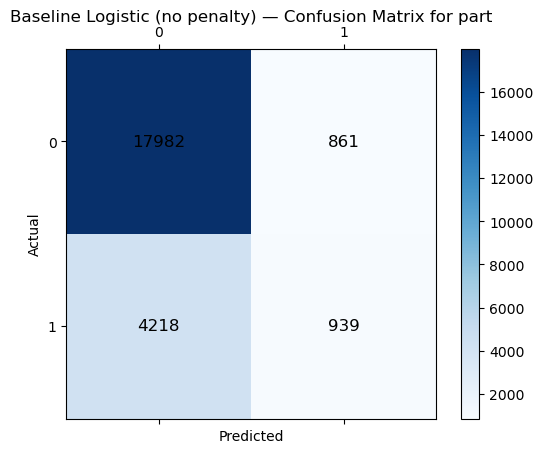

[Baseline] Random Forest trained in 0.91 seconds.
Accuracy: 0.861, Precision: 0.706, Recall: 0.603, F1: 0.651


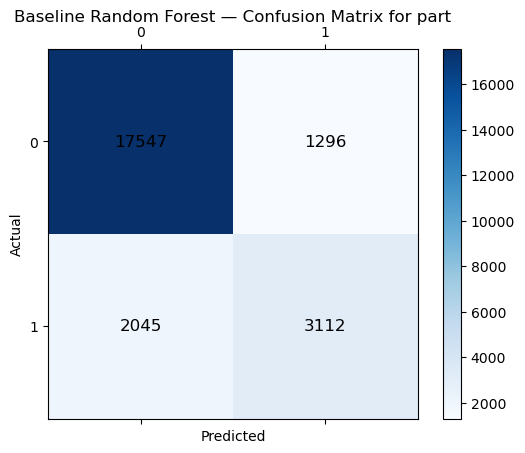

[Baseline] Logistic (no penalty) trained in 1.51 seconds.
Accuracy: 0.711, Precision: 0.695, Recall: 0.705, F1: 0.700


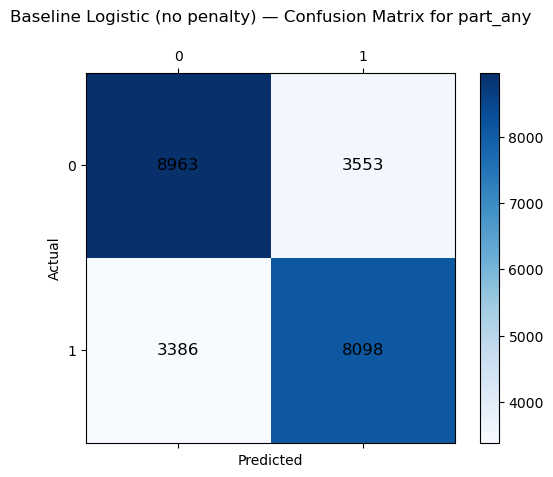

[Baseline] Random Forest trained in 1.03 seconds.
Accuracy: 0.835, Precision: 0.815, Recall: 0.848, F1: 0.831


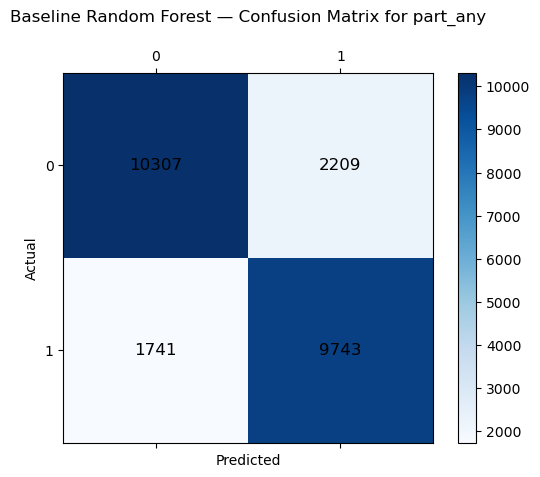


=== Running Augmented Models ===
Augmented preprocessing finished in 0.14 seconds.
Training shape: (96000, 25), Test shape: (24000, 25)
[Augmented] Logistic (CV) trained in 2.58 seconds.
Accuracy: 0.831, Precision: 0.640, Recall: 0.486, F1: 0.552


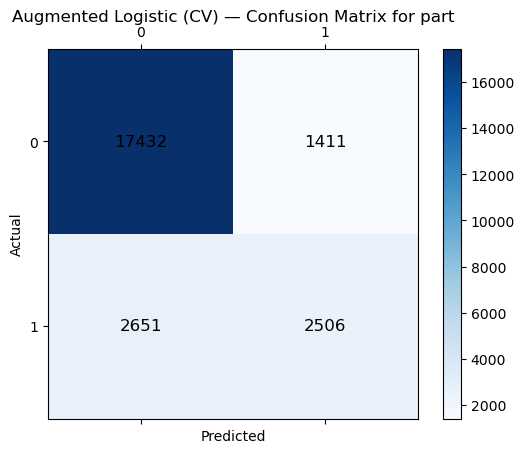

[Augmented] Random Forest trained in 1.92 seconds.
Accuracy: 0.980, Precision: 0.964, Recall: 0.941, F1: 0.953


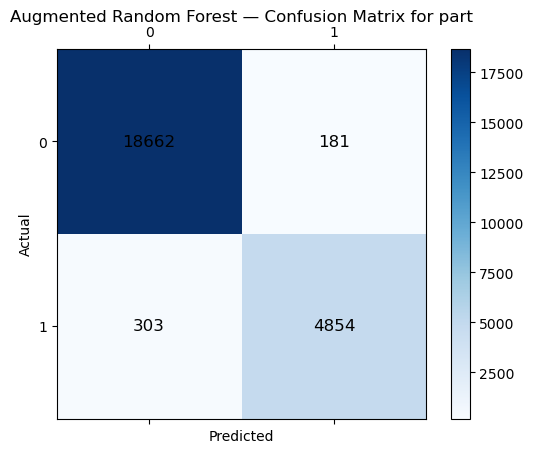

[Augmented] Logistic (CV) trained in 2.60 seconds.
Accuracy: 0.831, Precision: 0.821, Recall: 0.826, F1: 0.823


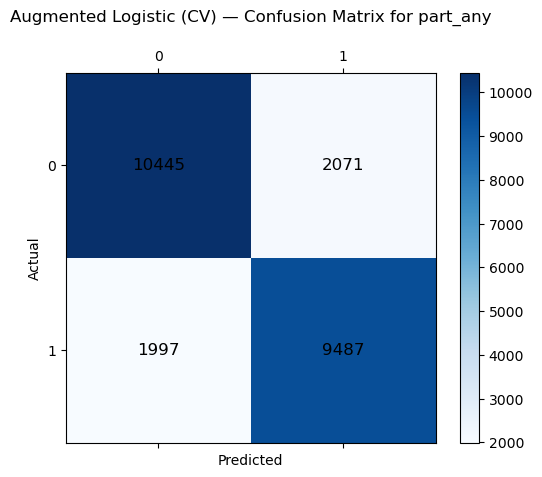

[Augmented] Random Forest trained in 1.58 seconds.
Accuracy: 0.983, Precision: 0.981, Recall: 0.985, F1: 0.983


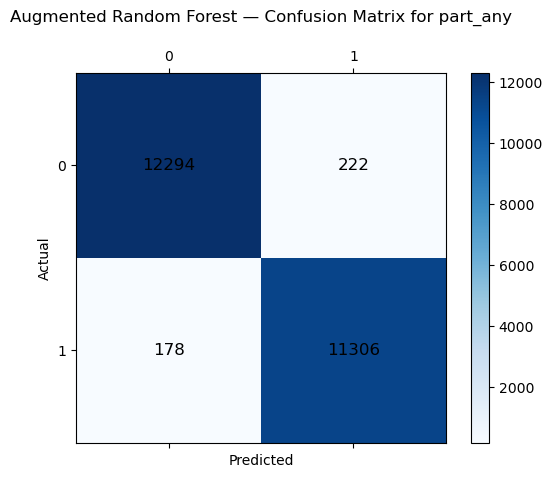

In [14]:
# ============================================
# Part 3.3 — Run All Models (Baseline and Augmented)
# ============================================

# Initialize a list to store evaluation metrics for all models
results = []

# Loop over feature sets (Baseline and Augmented)
for label, cfg in feature_sets.items():
    print(f"\n=== Running {label} Models ===")

    # Build preprocessing pipeline for current feature set
    preprocessor = build_preprocessor(cfg['categorical'], cfg['numeric'], cfg['binary'])

    # Preprocess the training and test data
    start_time = time.time()

    # Fit on training set and transform both training and test sets
    X_train_proc = preprocessor.fit_transform(X_train[cfg['features']])
    X_test_proc = preprocessor.transform(X_test[cfg['features']])

    end_time = time.time()

    # Report preprocessing time and resulting data shapes
    print(f"{label} preprocessing finished in {end_time - start_time:.2f} seconds.")
    print(f"Training shape: {X_train_proc.shape}, Test shape: {X_test_proc.shape}")

    # Determine whether to use cross-validation (only for augmented models)
    use_cv = True if label == 'Augmented' else False

    # Train and evaluate models for both outcomes
    for outcome, y_train, y_test in [('part', y_train_part, y_test_part), ('part_any', y_train_any, y_test_any)]:
        run_models(X_train_proc, X_test_proc, y_train, y_test, label, results, use_cv=use_cv)


In [15]:
# --------------------------------------
# Summary Table
# --------------------------------------

# Create DataFrame from results
results_df = pd.DataFrame(results, columns=['Model', 'Outcome', 'Accuracy', 'Precision', 'Recall', 'F1'])

# Sort model names within each outcome by F1 score
results_df = results_df.sort_values(by=['Outcome', 'F1'], ascending=[True, False])

# Round for readability
results_df = results_df.round(3).reset_index(drop=True)

# Display
print("\n=== Classification Summary Table ===")
display(results_df)



=== Classification Summary Table ===


,Model,Outcome,Accuracy,Precision,Recall,F1
0,Augmented Random Forest,part,0.980,0.964,0.941,0.953
1,Baseline Random Forest,part,0.861,0.706,0.603,0.651
2,Augmented Logistic (CV),part,0.831,0.640,0.486,0.552
3,Baseline Logistic (no penalty),part,0.788,0.522,0.182,0.270
4,Augmented Random Forest,part_any,0.983,0.981,0.985,0.983
5,Baseline Random Forest,part_any,0.835,0.815,0.848,0.831
6,Augmented Logistic (CV),part_any,0.830,0.821,0.826,0.823
7,Baseline Logistic (no penalty),part_any,0.711,0.695,0.705,0.700


#### Predicting Stock Market Participation
This section addresses three questions:
*   whether stock market participation can be predicted using classification models,
*   how well different models perform in predicting participation, and
*   which outcome variable is harder to predict (part for direct stockholding or part_any for any stockholding), and how augmented models compare to baseline models.

##### **Can we predict stock market participation using classification models?**
Classification models can predict stock market participation with considerable success, but predictive accuracy depends critically on model flexibility and the richness of available features. Baseline logistic regression models, estimated with limited demographic variables, perform poorly, particularly when predicting direct stockholding (`part`), reflecting the complexity of participation behavior that simple linear structures fail to capture. Baseline Random Forest classifiers perform better, especially for predicting any stockholding (`part_any`), by exploiting nonlinearities and interaction effects. However, substantial gains are only realized when expanding the feature set with financial variables and risk preferences. Augmented models, particularly the Augmented Random Forest, achieve near-perfect accuracy, precision, recall, and F1 scores for both direct (`part`) and any (`part_any`) stockholding, illustrating the importance of both flexible classification methods and comprehensive covariates for accurate prediction.


##### **Baseline Models (Part 3.2)**
Baseline models demonstrate limited ability to predict stock market participation when trained on sparse feature sets. Baseline logistic regression models achieve modest predictive performance. For direct stockholding (`part`), the baseline logistic regression model attains an F1 score of only 0.270, indicating poor predictive power. Performance improves when predicting any stockholding `(part_any`), with an F1 score of 0.700 and an accuracy of 0.711, which is substantially better than random guessing but still modest compared to more flexible models.

Baseline Random Forest classifiers perform substantially better than logistic regressions. When predicting direct stockholding (`part`), the Baseline Random Forest achieves an F1 score of 0.651, while for any stockholding (`part_any`), it reaches an F1 score of 0.831.

Comparing the two outcomes, it is clear that predicting any stockholding (`part_any`) is consistently easier than predicting direct stockholding (`part`). Across all baseline models, accuracy, precision, recall, and F1 scores are higher for part_any. This likely reflects that any stockholding shows broader and more inclusive behavior, while direct stockholding, being less common, may depend more heavily on individual-specific preferences and unobserved factors that are not easily captured by observable covariates.

In summary, baseline models achieve meaningful improvements over random guessing, particularly when using Random Forests. However, their predictive performance remains limited overall, and predicting direct stockholding (`part`) remains more challenging than predicting any stockholding (`part_any`).


##### **Augmented Models and Overall Comparison (Part 3.3)**
Expanding the feature set with financial, risk preference, and detailed demographic variables leads to substantial improvements in predictive performance. Augmented logistic regression models achieve higher F1 scores than their baseline counterparts across both outcomes. For direct stockholding (`part`), the Augmented Logistic Regression achieves an F1 score of 0.552, compared to 0.270 for the baseline logistic model. For any stockholding (`part_any`), it achieves an F1 score of 0.823, compared to 0.700 in the baseline specification.

The most substantial improvements occur when using Random Forest classifiers. The Augmented Random Forest achieves an F1 score of 0.953 for direct stockholding (`part`) and 0.983 for any stockholding (`part_any`). Compared to the Baseline Random Forest models, which achieved F1 scores of 0.651 for part and 0.831 for part_any, the gains are particularly large for direct stockholding. This substantial increase highlights the importance of both model flexibility and feature richness in capturing the complex determinants of stock market participation.

Despite the strong performance for both outcomes, predicting direct stockholding (`part`) remains more challenging overall. Even augmented models achieve slightly lower F1 scores for part than for part_any, reflecting the greater behavioral heterogeneity and selectivity associated with direct investment decisions.

In conclusion, augmentation of feature sets significantly enhances model performance relative to baseline specifications, and Random Forest classifiers consistently outperform logistic regressions. The Augmented Random Forest trained on part_any achieves the highest overall predictive performance, but the most significant relative improvement from baseline to augmentation occurs for direct stockholding (`part`).



## Part 4: Exploratory Data Analysis of Risky Share

This part examines the conditional risky share, defined as the fraction of financial assets invested in equities among households that directly participate in the stock market. We restrict attention to households with `part=1`, corresonding to those who directly hold stock or stock mutual funds, and thus are likely to have made active portfolio allocation choices.

The `risky_share` variables is constructed as the ratio of `equity` to `finassets`, measuring the share of financial wealth allocated to risky assets. Observations with missing and undefined `risky_share` are excluded, resulting in a sample of approximately 25,000 households.

We conduct exploratory analysis to understand variation in the risky share across the population. Specifically, we (i) compute correlations between `risky_share` and other household characteristics (excluding direct predictors), and (ii) analyze how average risky share varies across key demographic and financial groups.

### Step 4.1: Correlation Analysis

We first compute the absolute correlations between `risky_share` and all other numeric variables, excluding `equity`, `stocks`, `stkmutfnd`, `part`, `part_any`, `stratum`, and `risky_share` itself.

The table below presents the 20 variables most strongly ocrrelated with `risky_share`, providing initial insights into the household factors associated with differences in risky asset allocation among stockholding households.

In [16]:
# ============================================
# Part 4.1 — Filter and Correlation Analysis for Risky Share
# ============================================

# Filter to households that directly participate
part_sample = df[df['part'] == 1].copy()                                          # Select direct stockholders only
part_sample['risky_share'] = part_sample['equity'] / part_sample['finassets']     # Compute risky share
part_sample = part_sample.replace([np.inf, -np.inf], np.nan)                      # Remove infinite values
part_sample = part_sample.dropna(subset=['risky_share'])                          # Drop missing risky_share values

# Print observations in part_sample
print(f"Observations in part_sample: {len(part_sample)}")

# Correlation analysis: exclude direct predictors and risky_share itself
corrs = part_sample.corr(numeric_only=True)['risky_share']                                              # Correlate risky_share with all numeric vars
corrs = corrs.drop(['risky_share', 'equity', 'stocks', 'stkmutfnd', 'part', 'part_any', 'stratum'])     # Drop direct predictors and related variables
corrs = corrs.reindex(corrs.abs().sort_values(ascending=False).head(20).index)                          # Select top 20 variables most strongly ocrrelated

# Display results
print("Top 20 most correlated variables with risky_share:")
print(corrs)

Observations in part_sample: 25787
Top 20 most correlated variables with risky_share:
liqassets_rank    -0.156217
finassets          0.125266
finassets_rank     0.124821
takefinrisk        0.118377
assets             0.116984
networth           0.108602
houses             0.099472
year               0.098043
networth_rank      0.096203
assets_rank        0.096175
educ               0.094874
debt               0.094242
college            0.094211
liqassets         -0.093858
networth_decile    0.092551
mortages           0.089467
totloanpay         0.085994
houses_rank        0.082122
weight            -0.077728
finlit             0.077563
Name: risky_share, dtype: float64


The exploratory correlation analysis shows that the risky share is moderately associated with household financial resources and risk preferences. Households with higher financial assets (`finassets`, `finassets_rank`) and greater overall wealth (`assets`, `networth`) allocate a larger share of their portfolios to equities. Higher financial literacy (`finlit`) and greater risk tolerance (`takefinrisk`) are also linked to higher risky shares, underscoring the importance of both knowledge and willingness to bear risk in shaping investment decisions. Conversely, higher liquidity holdings (`liqassets`, `liqassets_rank`) are negatively correlated with risky share, consistent with more risk-averse households maintaining safer, more liquid portfolios. Educational attainment (`educ`, `college`) is positively associated with risky share, further highlighting the role of human capital in financial decision-making.

That said, it's important to remember that these are just correlations. They don’t imply any causal relationships, and they only reflect linear associations, potentially missing important non-linear effects. Some variables may also be related to the definition of risky share (like `finassets`), so we interpret the strength and direction of correlations with caution.

### Step 4.2: Exploratory Graphical Analysis

In this step, we replicate the exploratory approach from Part 2, plotting the average conditional risky share across key demographic and financial groups. Specifically, we display average risky shares by survey year, net worth decile, income decile, age group, education level, marital status and sex, race, employment status, and financial risk tolerance.

These plots provide a descriptive overview of how equity allocations vary within the stockholding population.


--- Generating Part 4: Conditional Risky Share Plots ---


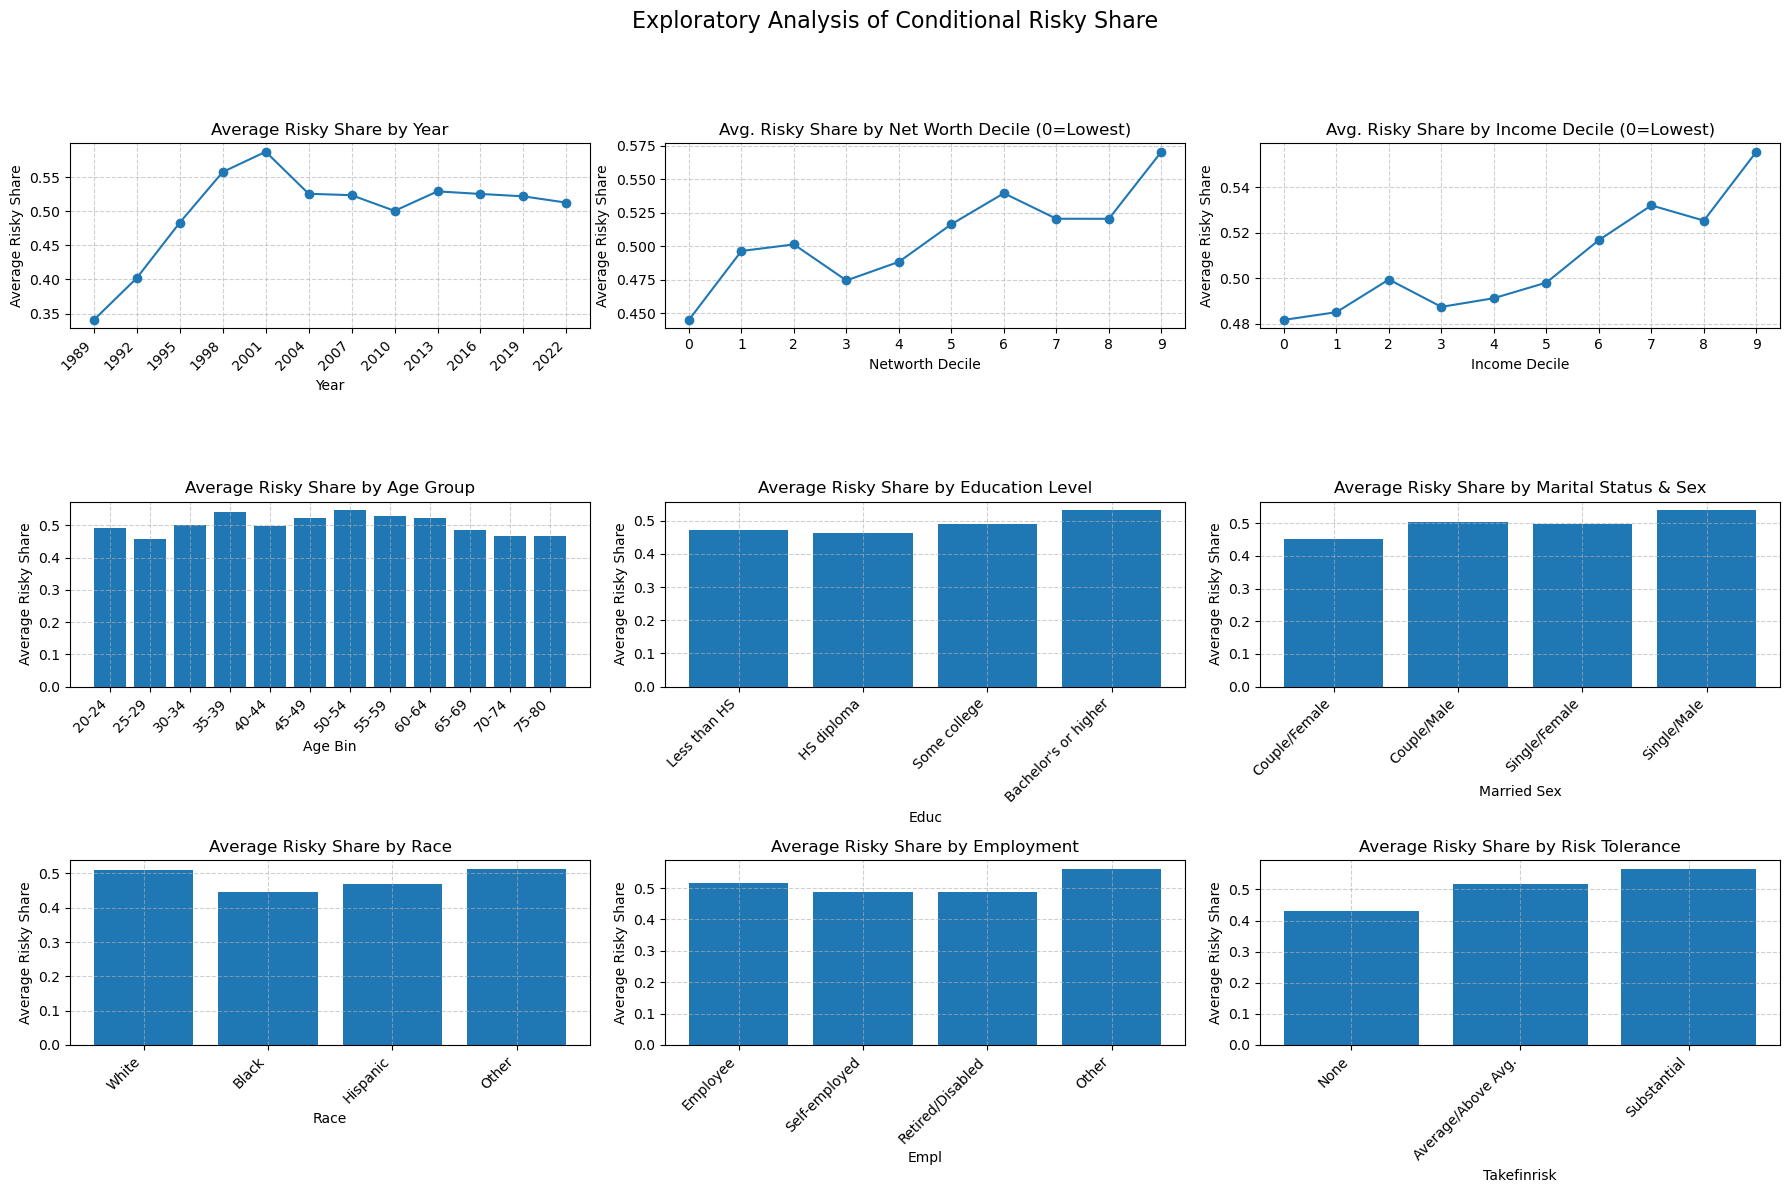

In [17]:
# ============================================
# Part 4 — Execute Plotting for Conditional Risky Share
# ============================================

# Create derived variables within the filtered sample
part_sample['networth_decile'] = pd.qcut(part_sample['networth_rank'], 10, labels=False, duplicates='drop')                                      # Net worth deciles
part_sample['income_decile'] = pd.qcut(part_sample['income_rank'], 10, labels=False, duplicates='drop')                                          # Income deciles
age_bins = list(range(20, 81, 5))                                                                                                                # Create 5-year bins
age_labels = [f"{a}-{a+4}" if a < 75 else "75-80" for a in age_bins[:-1] ]                                                                       # Custom last bin
part_sample['age_bin'] = pd.cut(part_sample['age'], bins=age_bins, labels=age_labels, right=True)                                                # Age groups
part_sample['married_sex'] = part_sample['married'].map({0: 'Single', 1: 'Couple'}) + '/' + part_sample['female'].map({0: 'Male', 1: 'Female'})  # Marital status and sex combined

# Define label mappings for categorical variables
educ_labels = {1: 'Less than HS', 2: 'HS diploma', 3: 'Some college', 4: "Bachelor's or higher"}  # Education labels
race_labels = {1: 'White', 2: 'Black', 3: 'Hispanic', 4: 'Other'}                                 # Race labels
empl_labels = {1: 'Employee', 2: 'Self-employed', 3: 'Retired/Disabled', 4: 'Other'}              # Employment labels
risk_labels = {0: 'None', 1: 'Average/Above Avg.', 2: 'Substantial'}                              # Risk tolerance labels

# Configure plotting settings
plot_configs_pt4 = [
    ('year', ['risky_share'], 'line', 'Average Risky Share by Year', None, 45, None, "Average Risky Share"),
    ('networth_decile', ['risky_share'], 'line', 'Avg. Risky Share by Net Worth Decile (0=Lowest)', None, 0, None, "Average Risky Share"),
    ('income_decile', ['risky_share'], 'line', 'Avg. Risky Share by Income Decile (0=Lowest)', None, 0, None, "Average Risky Share"),
    ('age_bin', ['risky_share'], 'bar', 'Average Risky Share by Age Group', None, 45, None, "Average Risky Share"),
    ('educ', ['risky_share'], 'bar', 'Average Risky Share by Education Level', educ_labels, 45, sorted(educ_labels.keys()), "Average Risky Share"),
    ('married_sex', ['risky_share'], 'bar', 'Average Risky Share by Marital Status & Sex', None, 45, None, "Average Risky Share"),
    ('race', ['risky_share'], 'bar', 'Average Risky Share by Race', race_labels, 45, sorted(race_labels.keys()), "Average Risky Share"),
    ('empl', ['risky_share'], 'bar', 'Average Risky Share by Employment', empl_labels, 45, sorted(empl_labels.keys()), "Average Risky Share"),
    ('takefinrisk', ['risky_share'], 'bar', 'Average Risky Share by Risk Tolerance', risk_labels, 45, sorted(risk_labels.keys()), "Average Risky Share")
]

# Generate and display the plot grid
print("\n--- Generating Part 4: Conditional Risky Share Plots ---")
plot_analysis_grid(
    df=part_sample,                                                      # Filtered dataset (direct participants only)
    configs=plot_configs_pt4,                                            # Plot configurations
    num_cols=3,                                                          # 3 plots per row
    figure_title="Exploratory Analysis of Conditional Risky Share",      # Overall title
    default_ylabel="Average Risky Share",                                # Default Y label
    show_legend=False                                                    # No legend needed (only risky_share plotted)
)


#### **Conditional Risky Share Patterns**

This section addresses two questions:
*   the fraction of financial wealth that households hold in stocks and stocks mutual funds, conditional on participation, and
*   the extent to which this conditional risky share varies across the population.

Conditional on participation, U.S. households allocate a substantial fraction of their financial wealth to risky assets. The average conditional risky share increased from approximately 34 percent in 1989 to nearly 59 percent by 2001. Since the early 2000s, the average has declined slightly, stabilizing between 50 and 53 percent across subsequent survey years.

Regarding variation across the population, differences in the conditional risky share are evident but less systematic compared to participation rates. Financial characteristics such as net worth and income are associated with some variation, although the patterns are nonlinear. Across the net worth distribution, the risky share rises at lower deciles but exhibits local declines between the second and third deciles and again between the sixth and seventh deciles. A similar pattern is observed across the income distribution, with a general upward trend but with irregularities at lower and middle deciles. These findings suggest that financial resources influence portfolio risk-taking, but the relationship is not smooth and displays significant heterogeneity.

Age-related variation is present but less pronounced. Risky shares peak among households aged 35–39 and again at 50–54 years, followed by a gradual decline at older ages. The double-peaked structure indicates that investment behavior over the life course is not uniform.

Socio-demographic factors such as education, marital status, race, and employment status are associated with only modest differences in risky share allocations. Households with a bachelor's degree, single males, White and "Other" racial groups, and households not in the labor force allocate slightly larger shares to risky assets compared to their counterparts. However, in all cases, the magnitude of these differences remains small and does not reveal strong systematic patterns.

Risk tolerance is the characteristic most strongly associated with risky share allocations. Households reporting greater willingness to take financial risks consistently allocate larger fractions of their financial wealth to equities.

In conclusion, conditional on participation, households allocate around 50 to 59 percent of their financial wealth to risky assets on average. While financial resources such as net worth and income contribute to variation in the risky share, the relationships are nonlinear and irregular. Other observable characteristics explain only modest differences, highlighting the substantial heterogeneity in household portfolio behavior.

Given the lower degree of variation in the conditional risky share relative to participation rates, it is anticipated that predictive accuracy will be modest. However, the analysis remains important for understanding systematic patterns in equity allocations among participating households.



## Part 5: Predicting the Conditional Risky Share

Following the exploratory analysis in part 4, we now turn to formally modeling the conditional risky share. Given that the variation in risky share exhibit small differences , and nonlinear patters across covariates, we expect predictive models to achieve only moderate success in capturing risky share allocations.

We proceed by constructing regression models using scikit-learn, starting with a baseline intercept-only model as a reference point. We then augment the feature set and compare multiple linear and regularized regression models. Model evaluation is conducted using the root mean squared error (RMSE) and the coefficient of determination R² on an out-of-sample test set. Given the limited exlonatory content of standard household characteristics, we expect that even augmented models may capture only part of the underlying variation.

### Step 5.1: Train-Test Split

To evaluate model performance fairly, we split the sample into a training and a test set. Following best practices for repeated cross-sectional data, we perform a stratified train-test split based on the survey year to ensure proportional representation of each survey wave across subsamples.

We retain 80% of the observations for training and reserve 20% for testing. The stratification ensures that temporal differences in risky share behavior are preserved in both sets, avoiding bias in model evaluation.

In [18]:
# ============================================
# Part 5.1 — Train-Test Split by year
# ============================================

print("\n--- Part 5.1: Train-Test Split ---")

# Create a copy of the full sample to avoid modifying the original dataset
part_sample = part_sample.copy()

# Split the data into training and testing sets (stratified by year)
train_sample, test_sample = train_test_split(
    part_sample, test_size=0.2,     # 20% of the data used for testing
    stratify=part_sample['year'],   # Ensure the year distribution is preserved for both sets
    random_state=RANDOM_STATE       # Set random seed for reproducibility
)

# Define the target variable (risky_share) for training and testing sets
y_train = train_sample['risky_share']
y_test = test_sample['risky_share']

# Print the number of observations in training and test sets
print(f"Training observations: {len(y_train)}")
print(f"Test observations:     {len(y_test)}")






--- Part 5.1: Train-Test Split ---
Training observations: 20629
Test observations:     5158


### Step 5.2: Mean Baseline (Intercept-Only)

To establish a benchmark for model evaluation, we fit an intercept-only regression model that predicts the mean of the conditional risky share observed in the training sample. This model contains no explanatory variables and assumes that the optimal prediction for all households is simply the sample mean of the training outcomes. Predicitons for the test sample are generated by assigning this mean value to every observation. As the intercept-only model does not incorporate any predictors, it is expected to achieve an R² close to zero by construction.

In [19]:
# ============================================
# Part 5.2 — Baseline Model
# ============================================

print("\n--- Part 5.2: Baseline Predictor (Intercept-Only) ---")

# Compute the mean of the training target (risky share)
mean_train = y_train.mean()

# Predict the mean for all test observations (intercept-only model)
y_pred_baseline = np.full_like(y_test, fill_value=mean_train, dtype=float)

# Calculate RMSE for the baseline predicitons
baseline_rmse = np.sqrt(mean_squared_error(y_test, y_pred_baseline))
print(f"Baseline RMSE: {baseline_rmse:.4f}")

# Calculate R-squared for the baseline predictions
baseline_r2 = r2_score(y_test, y_pred_baseline)
print(f"Baseline R²:   {baseline_r2:.4f}")

# Store the baseline results for later comparison
results = [("Mean Baseline", baseline_rmse, baseline_r2)]



--- Part 5.2: Baseline Predictor (Intercept-Only) ---
Baseline RMSE: 0.2807
Baseline R²:   -0.0005


The intercept-only model achieves and RMSE of 0.2807 and an R² of -0.0005 on the test sample. As expected, the R² is approximately zero, confirming that the model has no explonatory power beyond predicting the unconditional mean. The RMSE provides a baseline level of prediction error against which the performance of more complex models can be assessed.

### Step 5.3: Prediction with Additional Features


The augmented predictors include ranked measures of the financial resources (`liqassets_rank`, `networth_rank`, `income_rank`). While `finassets_rank` was included in Part 3, it is exluded here due to its mechanical relationship with the target variable, as `risky_share` is defined as `equity/finassets`.

Behavioral factors such as fincancial literacy (`finlit`) and risk tolerance (`takefinrisk`) are also included, given their role in shaping household investment decisions. The model further incorporates core demographic characteristics - `age`, `educ`, `married`, `female`, `kids`, `race`, `empl`, and `owner` - as well as the `year` variable as a control.

All preprocessing is conducted using `SimpleImputer` and `StandardScaler` for numeric features, and `SimpleImputer` with OneHotEncoder for categorical features. Numeric variables are imputed using the median and standardized to have zero mean and unit variance. Categorical variables are imputed using the most frequent category and then one-hot encoded, omitting the first category to avoid multicollinearity. Binary indicators such as `female`, `married` and `owner` are treated as categorical variables, as one-hot encoding of binary variables produces the same effect as passthrough while maintaining consistent imputation handling. This ensures that no observations are dropped, and the full training and test samples are retained after imputation.

Although moderate to high correlations exist among financial variables, no further adjustments are applied. The models estimated, namely Ridge, Lasso, Elastic Net, and Principal Component Regression, are well suited to handle correlated predictors via regularization or dimensionality reduction. While unregularized linear regression is more sensitive to multicollinearity, the primary objective is to identify the model that yields the best predictive performance on out-of-sample data. Regularized models are thus expected to outperform ordinary least squares. Multicollinearity diagnostics have been assessed and are considered manageable given the methods employed.

This preprocessing framework ensures that the predictor set is numerically stable, theoretically coherent, and well suited for accurately modeling the conditional risky share. The focus remains firmly on optimizing predictive accuracy rather than on structural interpretation of model coefficients.

In [20]:
# ============================================
# Part 5.3
# ============================================
# Define selected features
selected_features = [
    # Financial Ranks (using ranks for better numerical stability)
    #'finassets_rank',
    'liqassets_rank',
    'networth_rank',
    'income_rank',

    # Risk Attitude & Knowledge
    'takefinrisk',
    'finlit',
    # Demographics
    'age',
    'educ',
    'married',
    'female',
    'kids',
    'race',
    # Employment & Other
    'empl',
    'owner',
    # Year (control)
    'year'
]


# Define predictors (we use SimpleImputer)
X_train = train_sample[selected_features].copy()
X_test = test_sample[selected_features].copy()

# Preprocessing: separate numeric and categorical features
numeric_features = ['liqassets_rank', 'networth_rank', 'income_rank', 'age', 'kids']
categorical_features = ['takefinrisk', 'year', 'empl', 'married', 'female', 'owner', 'educ', 'race', 'finlit']


numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(drop='first', sparse_output=False))
])

base_preprocessor = ColumnTransformer([
    ('num', numeric_pipeline, numeric_features),
    ('cat', categorical_pipeline, categorical_features)
])

#### **Polynomial Degree Selection for Linear Regression**

To capture potential nonlinearities in the determinants of the conditional risky share, polynomial feature expansions of varying degrees are evaluated. An initial tuning exercise considered polynomial degrees up to five and found that a second-degree specification minimized cross-validated prediction error. Based on this result, the final search range was restricted to degrees zero through two to improve computational efficiency without affecting model selection.

For each degree, a full modeling pipeline is constructed, incorporating imputation, scaling, polynomial expansion, and linear regression. Five-fold cross-validation is used to estimate the root mean squared error (RMSE) on the training set. Degree two is confirmed to yield the best predictive performance, striking an appropriate balance between model flexibility and tractability.

This tuning strategy ensures that the final linear model captures relevant nonlinear relationships without introducing excessive complexity or computational burden.



In [21]:
# ============================================
# Polynomial Degree Tuning
# ============================================

print("\n--- Tuning Polynomial Degree ---")

# Define candidate degrees for polynomial features expansion
degrees = np.arange(1,3) # Previously tested up to 5; limited to 3 since degree 2 was optimal and for faster computation
rmse_cv = []           # Store cross-validated RMSE for each degree

# Loop over each degree and evaluate model performance
for d in degrees:
    pipe = Pipeline([
        ('preprocess', base_preprocessor),                           # Apply preprocessing
        ('poly', PolynomialFeatures(degree=d, include_bias=False)),  # Polynomial features
        ('model', LinearRegression())                                # Linear regression
    ])

    # Perform cross-validation
    score = cross_val_score(pipe, X_train, y_train, cv=5, scoring='neg_root_mean_squared_error')
    rmse_cv.append(-score.mean())  # Convert to positive RMSE

# Select the degree with the lowest cross-validated RMSE
best_degree = degrees[np.argmin(rmse_cv)]
print(f"Best polynomial degree: {best_degree}")


--- Tuning Polynomial Degree ---
Best polynomial degree: 2


##### **Model Specification, Tuning and Evaluation**

To ensure a fair comparison across models, we apply the same polynomial degree (2) to all estimators in this section. This degree was chosen based on cross-validated RMSE minimization in the linear regression model, and applying it consistently across models ensures that performance differences arise from the modeling approach rather than differences in feature specification.

The augmented predictor set is modeled using a unified preprocessing strategy consisting of median imputation, standardization, and one-hot encoding. To capture nonlinear relationships and interaction effects between predictors, a second-degree polynomial feature expansion is applied. This introduces both squared terms and two-way interaction terms among the input variables. Five models are estimated using this pipeline: ordinary least squares (with polynomial features), Ridge regression, Lasso regression, Elastic Net, and Principal Component Regression (PCR).

For Ridge, Lasso, and Elastic Net, hyperparameters are selected via five-fold cross-validation, optimizing the root mean squared error (RMSE). For PCR, the optimal number of principal components is chosen by minimizing cross-validated RMSE across a grid of up to 50 components. Model performance is evaluated on the test set using RMSE and R².

This approach ensures that predictive performance is prioritized over coefficient interpretation. Regularization and dimensionality reduction techniques help mitigate the effects of multicollinearity and high dimensionality. The modeling strategy is designed to deliver accurate and robust predictions of the conditional risky share across diverse household characteristics.

In [22]:
# ============================================
#  Model Fitting and Evaluation
# ============================================

# Set Up PolynomialFeatures with Best Degree
poly = PolynomialFeatures(degree=best_degree, include_bias=False)

# Define grid of regularization strengths (alphas) and l1 rations for Elastic Net
alphas = np.logspace(-4, 2, 100)
l1_ratios = [0.1, 0.5, 0.9]

# Set up pipelines for different models
pipe_lr = Pipeline([
    ('preprocess', base_preprocessor),    # Apply preprocessing
    ('poly', poly),                       # Add polynomial features
    ('model', LinearRegression())         # Ordinary least squares regression
])

pipe_ridge = Pipeline([
    ('preprocess', base_preprocessor),
    ('poly', poly),
    ('model', RidgeCV(alphas=alphas, scoring='neg_root_mean_squared_error'))
])

pipe_lasso = Pipeline([
    ('preprocess', base_preprocessor),
    ('poly', poly),
    ('model', LassoCV(alphas=alphas, cv=5, max_iter=10000, random_state=RANDOM_STATE))
])

pipe_elastic = Pipeline([
    ('preprocess', base_preprocessor),
    ('poly', poly),
    ('model', ElasticNetCV(alphas=alphas, l1_ratio=l1_ratios, cv=5, max_iter=20000, random_state=RANDOM_STATE))
])

# ============================================
# Tune Principal Component Regression (PCR)
# ============================================

print("\n--- Tuning PCR Components ---")

# Apply preprocessing to traning data (for PCA)
X_train_base = base_preprocessor.fit_transform(X_train)

# Set maximum number of components to test (50)
max_components = min(X_train_base.shape[1], 50)

pca_rmses = []        # Store RMSE for each number of components
best_rmse = np.inf    # Initialize best RMSE
optimal_n = 1         # Initialize best number of components

# Loop over possible numbers of principal components
for n in range(1, max_components + 1):
    pipe = make_pipeline(PCA(n_components=n), LinearRegression())
    score = cross_val_score(pipe, X_train_base, y_train, cv=5, scoring='neg_root_mean_squared_error')
    rmse = -score.mean()
    pca_rmses.append(rmse)
    if rmse < best_rmse:
        best_rmse = rmse
        optimal_n = n

print(f"Best PCR components: {optimal_n} (RMSE: {best_rmse:.4f})")

# Define final PCR pipeline with the optimal number of components
pipe_pcr = Pipeline([
    ('preprocess', base_preprocessor),
    ('pca', PCA(n_components=optimal_n)),
    ('model', LinearRegression())
])

# ============================================
# Fit and Evaluate All Models
# ============================================

# Initialize results list with baseline model results
results = [("Mean Baseline", baseline_rmse, baseline_r2)]

print("\n--- Fitting and Evaluating Models ---")

# Dictionary of models to train and evaluate
models = {
    "Linear Regression (Poly)": pipe_lr,
    "Ridge Regression (Poly)": pipe_ridge,
    "Lasso Regression (Poly)": pipe_lasso,
    "Elastic Net (Poly)": pipe_elastic,
    f"PCR ({optimal_n})": pipe_pcr
}

# Train and evaluate each model
for name, pipeline in models.items():
    print(f"\nFitting {name}...")
    start_time = time.time()
    pipeline.fit(X_train, y_train)    # Train model
    y_pred = pipeline.predict(X_test) # Predict on test set
    end_time = time.time()

    # Calculate RMSE and R-squared
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    # Store results
    results.append((name, rmse, r2))

    # Print selected hyperparameters if applicable
    if "Ridge" in name:
        print(f"  Best Alpha: {pipeline.named_steps['model'].alpha_:.4f}")
    elif "Lasso" in name:
        print(f"  Best Alpha: {pipeline.named_steps['model'].alpha_:.4f}")
    elif "Elastic Net" in name:
        print(f"  Best Alpha: {pipeline.named_steps['model'].alpha_:.4f}, L1 Ratio: {pipeline.named_steps['model'].l1_ratio_:.4f}")

# ============================================
# Summarize and Display Results
# ============================================
# Create results DataFrame and sort by RMSE
results_df = pd.DataFrame(results, columns=["Model", "RMSE", "R2"]).sort_values(by="RMSE").reset_index(drop=True)

print("\n--- Model Comparison ---")
print(f"Baseline RMSE: {baseline_rmse:.4f}")
print(results_df.round({"RMSE": 4, "R2": 4}).to_string(index=False))


--- Tuning PCR Components ---
Best PCR components: 33 (RMSE: 0.2582)

--- Fitting and Evaluating Models ---

Fitting Linear Regression (Poly)...

Fitting Ridge Regression (Poly)...
  Best Alpha: 4.0370

Fitting Lasso Regression (Poly)...
  Best Alpha: 0.0001

Fitting Elastic Net (Poly)...
  Best Alpha: 0.0002, L1 Ratio: 0.1000

Fitting PCR (33)...

--- Model Comparison ---
Baseline RMSE: 0.2807
                   Model   RMSE      R2
      Elastic Net (Poly) 0.2502  0.2052
 Ridge Regression (Poly) 0.2504  0.2039
 Lasso Regression (Poly) 0.2505  0.2027
Linear Regression (Poly) 0.2511  0.1990
                PCR (33) 0.2583  0.1527
           Mean Baseline 0.2807 -0.0005


##### **Predicting the Conditional Risky Share: Model Performance and Predictive Limits**
This section addresses two questions:
*   which regression model performs best in terms of predicting the conditional risky share, and
*   to what extent regression models can predict the conditional risky share effectively.

Among the estimated models, Elastic Net regression performs the best, achieving the lowest RMSE of 0.2502 and the highest R² of 0.2052. Ridge and Lasso regressions follow closely with nearly identical RMSEs of 0.2504 and 0.2505, and R² values of 0.2039 and 0.2027, respectively. These results show that regularized models with polynomial features yield meaningful gains over the mean baseline (RMSE of 0.2807, R²≈0), which captures no explanatory variation.

Ordinary least squares regression with polynomial terms performs slightly worse (RMSE of 0.2511, R² of 0.1990), highlighting that without regularization, multicollinearity and overfitting limit model performance in high-dimensional settings.

Principal Component Regression (PCR) using 33 components improves marginally on the baseline (RMSE of 0.2583, R² of 0.1527), but falls short of other methods. This reflects the trade-off in PCR: components are chosen to explain variance, not necessarily predictive power, which may lead to discarding useful signals.

Overall, while regression models can modestly predict the conditional risky share, the best model (Elastic Net) explains just over 20% of the variation. This underscores the inherent limits of prediction in this setting, due to unobserved preferences, behavioral noise, and measurement error. Nonetheless, the consistent improvements over the baseline validate that the use of flexible regularized modeling techniques capture meaningful structure in household investment behavior


## Timer: Stop and Report Total Excecution time

In [23]:
# Stop the total notebook timer
global_notebook_end_time = time.perf_counter()
total_elapsed_time = global_notebook_end_time - global_notebook_start_time

# Convert to min and seconds
total_minutes = int(total_elapsed_time // 60)
total_seconds = total_elapsed_time % 60

# Display results
print("\n" + "=" * 60)
print(f"Notebook execution finished at {time.strftime('%Y-%m-%d %H:%M:%S')}")
print(f"Total execution time: {total_minutes} minutes and {total_seconds:.2f} seconds")
print("=" * 60)


Notebook execution finished at 2025-04-09 17:54:12
Total execution time: 2 minutes and 4.19 seconds
